<a href="https://colab.research.google.com/github/samsarkar184/ML-Projects/blob/main/Iris_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(150, 4)
[2 1 0 0 0 1 0 0 2 1 1 2 2 1 2 0 2 0 2 1 1 0 1 2 0 1 2 0 1 2 1 2 2 0 2 0 2
 0 1 1 1 1 2 2 2 2 0 0 2 0 0 0 0 1 2 1 1 2 1 0 0 0 0 0 0 2 0 0 2 2 2 0 0 0
 1]
[2, 1, 0, 0, 0, 1, 0, 0, 2, 1, 1, 2, 2, 1, 2, 0, 2, 0, 2, 1, 1, 0, 1, 2, 0, 1, 2, 0, 1, 2, 1, 2, 2, 0, 2, 0, 2, 0, 1, 1, 1, 1, 2, 2, 2, 2, 0, 0, 2, 0, 0, 0, 0, 1, 2, 2, 1, 2, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 2, 2, 0, 0, 0, 1]
0.9866666666666667


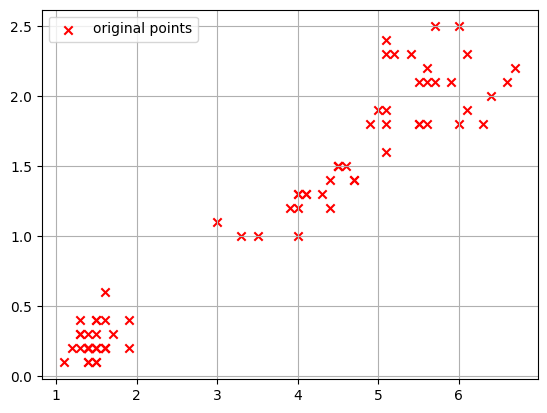

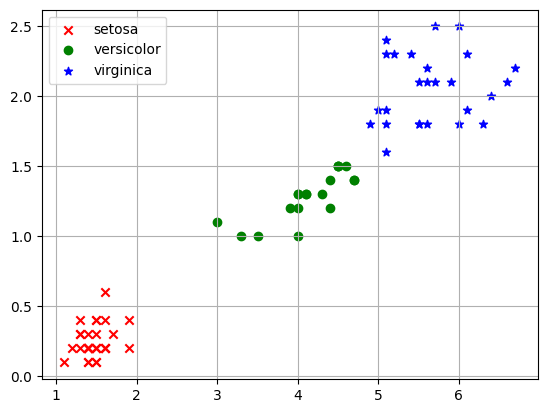

In [31]:
import numpy as np
from scipy.stats import multivariate_normal
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

def bayes_maximum_likelihood_classifier(X_train,y_train,X_test):
  #separation of classes
  X_setosa=X_train[y_train==0]
  X_versicolor=X_train[y_train==1]
  X_virginica=X_train[y_train==2]

  #computation of mean
  mean_setosa=np.mean(X_setosa,axis=0)
  mean_versicolor=np.mean(X_versicolor,axis=0)
  mean_virginica=np.mean(X_virginica,axis=0)
  cov_setosa=np.cov(X_setosa,rowvar=False)
  cov_versicolor=np.cov(X_versicolor,rowvar=False)
  cov_virginica=np.cov(X_virginica,rowvar=False)

  #computation of probability density
  pdf_setosa=multivariate_normal(mean=mean_setosa,cov=cov_setosa)
  pdf_versicolor=multivariate_normal(mean=mean_versicolor,cov=cov_versicolor)
  pdf_virginica=multivariate_normal(mean=mean_virginica,cov=cov_virginica)
  y_pred=[]
  #computation of likelihood
  for x in X_test:
    likelihood_setosa=pdf_setosa.pdf(x)
    likelihood_versicolor=pdf_versicolor.pdf(x)
    likelihood_virginica=pdf_virginica.pdf(x)

    if likelihood_setosa>likelihood_versicolor and likelihood_setosa>likelihood_virginica:
      y_pred.append(0)
    elif likelihood_versicolor>likelihood_setosa and likelihood_versicolor>likelihood_virginica:
      y_pred.append(1)
    else:
      y_pred.append(2)
  return y_pred


iris=load_iris()
print(iris.data.shape)
X=iris.data
y=iris.target

#shuffle the data
indices=np.random.permutation(len(X))
X=X[indices]
y=y[indices]
train_size=int(0.5*len(X))
X_train,X_test,y_train,y_test=X[:train_size],X[train_size:],y[:train_size],y[train_size:]
y_pred=bayes_maximum_likelihood_classifier(X_train,y_train,X_test)
print(y_test)
print(y_pred)
accuracy=np.mean(y_pred==y_test)
y_pred=np.array(y_pred)
print(accuracy)
plt.scatter(X_test[:,2],X_test[:,3],c='red',marker='x',label='original points')
plt.legend()
plt.grid(True)
plt.show()

plt.scatter(X_test[y_pred==0][:,2],X_test[y_pred==0][:,3],c='red',marker='x',label='setosa')
plt.scatter(X_test[y_pred==1][:,2],X_test[y_pred==1][:,3],c='green',marker='o',label='versicolor')
plt.scatter(X_test[y_pred==2][:,2],X_test[y_pred==2][:,3],c='blue',marker='*',label='virginica')
plt.legend()
plt.grid(True)
plt.show()
